# Flight Price Prediction — Data Cleaning & Feature Engineering

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, preprocess_data, create_features
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (50000, 10)


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,Air_India,Delhi,Morning,one,Early_Morning,Kolkata,Economy,19.75,40,7366
1,Vistara,Kolkata,Morning,one,Night,Mumbai,Business,9.83,42,64831
2,Vistara,Kolkata,Morning,one,Night,Bangalore,Economy,10.50,41,6195
3,Vistara,Chennai,Night,one,Morning,Delhi,Business,14.50,14,60160
4,Air_India,Bangalore,Afternoon,one,Night,Mumbai,Economy,8.25,20,6578


## 2. Handle Missing / Invalid Values

In [3]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df_clean = df.copy()

Missing values: 0
Duplicates: 60


## 3. Imputation

In [4]:
df_imputed = df_clean.copy()
print('NaN count:', df_imputed.isnull().sum().sum())

NaN count: 0


## 4. Distribution Comparison Before vs After Imputation

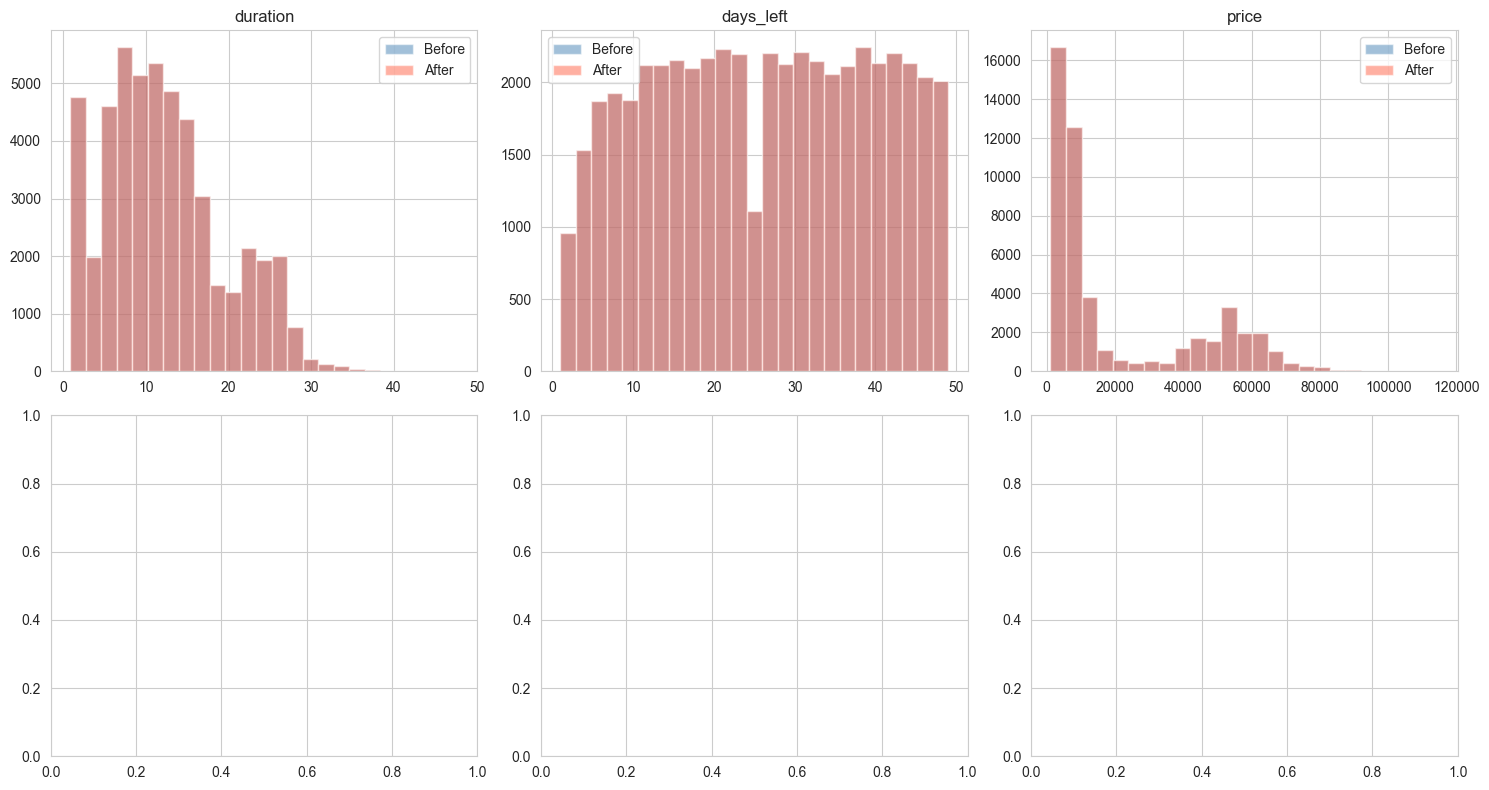

In [5]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
    if i >= 6: break
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=25, alpha=0.5, label='Before', color='steelblue')
    if col in df_imputed.columns:
        axes[i].hist(df_imputed[col], bins=25, alpha=0.5, label='After', color='tomato')
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

## 5. Feature Engineering

In [6]:
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

After feature engineering: (50000, 11)


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,log_duration
0,Air_India,Delhi,Morning,1,Early_Morning,Kolkata,Economy,19.75,40,7366,3.032546
1,Vistara,Kolkata,Morning,1,Night,Mumbai,Business,9.83,42,64831,2.382320
2,Vistara,Kolkata,Morning,1,Night,Bangalore,Economy,10.50,41,6195,2.442347
3,Vistara,Chennai,Night,1,Morning,Delhi,Business,14.50,14,60160,2.740840
4,Air_India,Bangalore,Afternoon,1,Night,Mumbai,Economy,8.25,20,6578,2.224624


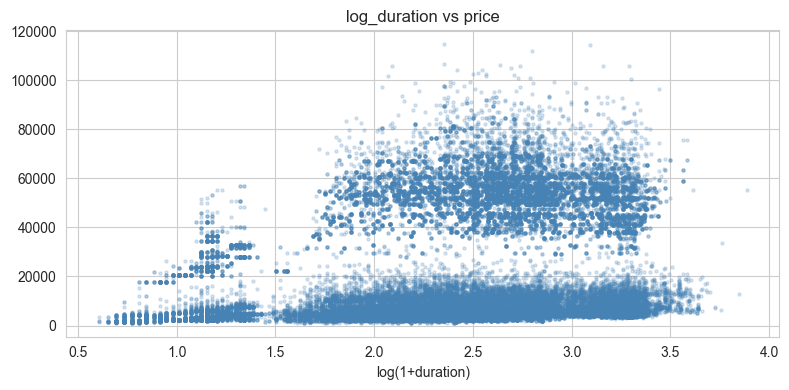

In [7]:
if 'log_duration' in df_feat.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(df_feat['log_duration'], df_feat['price'], alpha=0.2, s=5, color='steelblue')
    ax.set_title('log_duration vs price'); ax.set_xlabel('log(1+duration)')
    plt.tight_layout(); plt.show()

## 6. Encode Categorical Features

In [8]:
cat_cols = df_feat.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('Final shape:', df_encoded.shape)

Categorical columns: ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class']
Final shape: (50000, 31)


## 7. Verify & Save Cleaned Dataset

In [9]:
print('Missing values:', df_encoded.isnull().sum().sum())
print('Final shape:', df_encoded.shape)
df_encoded.to_csv('data/flights_cleaned.csv', index=False)
print('Saved -> data/flights_cleaned.csv')
df_encoded.head()

Missing values: 0
Final shape: (50000, 31)


Saved -> data/flights_cleaned.csv


,stops,duration,days_left,price,log_duration,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,departure_time_Early_Morning,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,1,19.75,40,7366,3.032546,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1
1,1,9.83,42,64831,2.382320,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
2,1,10.50,41,6195,2.442347,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1
3,1,14.50,14,60160,2.740840,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0
4,1,8.25,20,6578,2.224624,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1
